
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [2]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [3]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4", "day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [4]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [5]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [6]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")


Split -> train: 705 | val: 176


In [7]:
center, scale = standardize_graph_targets(g_train, g_val, robust=True)

In [8]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=2000,
    patience=100,
    num_workers=4,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
from src.data.ring_features import attach_precomputed_ring_features

K_MAX = 7

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

In [10]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP
from src.training.loop import train

num_layers_list = [3, 5, 7]
hidden_dims = [16, 32, 64, 2*64, 3*64, 4*64, 6*64]

trained_models = {}

for k in num_layers_list:
    family_name = f"GIN_L{k}"
    trained_models[family_name] = []

    for h in hidden_dims:
        print(f"\n=== Training {family_name} with hidden_dim={h} ===")

        model_kwargs = {
            "n_markers": int(g_train[0].x.size(1)),
            "hidden_dim": int(h),
            "num_layers": int(k),
            "dropout": 0.1,
            "residual": True,
            "norm": "batch",
            "train_eps": True,
        }

        model = GINCurvature(**model_kwargs)

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_models[family_name].append(model)


for k in num_layers_list:
    family_name = f"ring_L{k}"
    trained_models[family_name] = []

    for h in hidden_dims:
        print(f"\n=== Training {family_name} with hidden_dim={h} ===")     

        model_kwargs = {
            "n_markers": int(g_train[0].x.size(1)),
            "k_hops": int(k),
            "hidden_dim": int(h),
            "dropout": 0.1,
            "norm": "batch",
            "feature_attr": "x_ring",
        }

        model = RingFractionMLP(**model_kwargs)

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_models[family_name].append(model)



=== Training GIN_L3 with hidden_dim=16 ===
epoch 001 | train loss 1.3124 mae 1.1281 | val loss 1.2174 mae 1.0390
epoch 002 | train loss 1.1095 mae 1.0859 | val loss 1.1228 mae 1.0282
epoch 003 | train loss 1.0019 mae 1.0519 | val loss 1.0371 mae 1.0015
epoch 004 | train loss 0.9442 mae 1.0267 | val loss 0.9691 mae 0.9785
epoch 005 | train loss 0.9118 mae 1.0111 | val loss 0.9296 mae 0.9648
epoch 006 | train loss 0.8949 mae 1.0018 | val loss 0.9039 mae 0.9569
epoch 007 | train loss 0.8796 mae 0.9934 | val loss 0.8849 mae 0.9527
epoch 008 | train loss 0.8634 mae 0.9866 | val loss 0.8700 mae 0.9472
epoch 009 | train loss 0.8541 mae 0.9814 | val loss 0.8576 mae 0.9416
epoch 010 | train loss 0.8460 mae 0.9768 | val loss 0.8456 mae 0.9343
epoch 011 | train loss 0.8327 mae 0.9717 | val loss 0.8303 mae 0.9311
epoch 012 | train loss 0.8251 mae 0.9674 | val loss 0.8193 mae 0.9295
epoch 013 | train loss 0.8183 mae 0.9652 | val loss 0.8109 mae 0.9330
epoch 014 | train loss 0.8127 mae 0.9625 | val

In [11]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, scale, center):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        # aggregate storage
        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device,
                scale,
                center,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        # stack aggregate arrays across model depth / family member index
        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                vals = fam_aggregate[agg_name][metric]
                fam_aggregate_stacked[agg_name][metric] = np.asarray(vals, dtype=float)

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


eval_results = evaluate_family_models(
    trained_models=trained_models,
    eval_subgraphs=g_val,
    device=device,
    scale=scale,
    center=center,
)

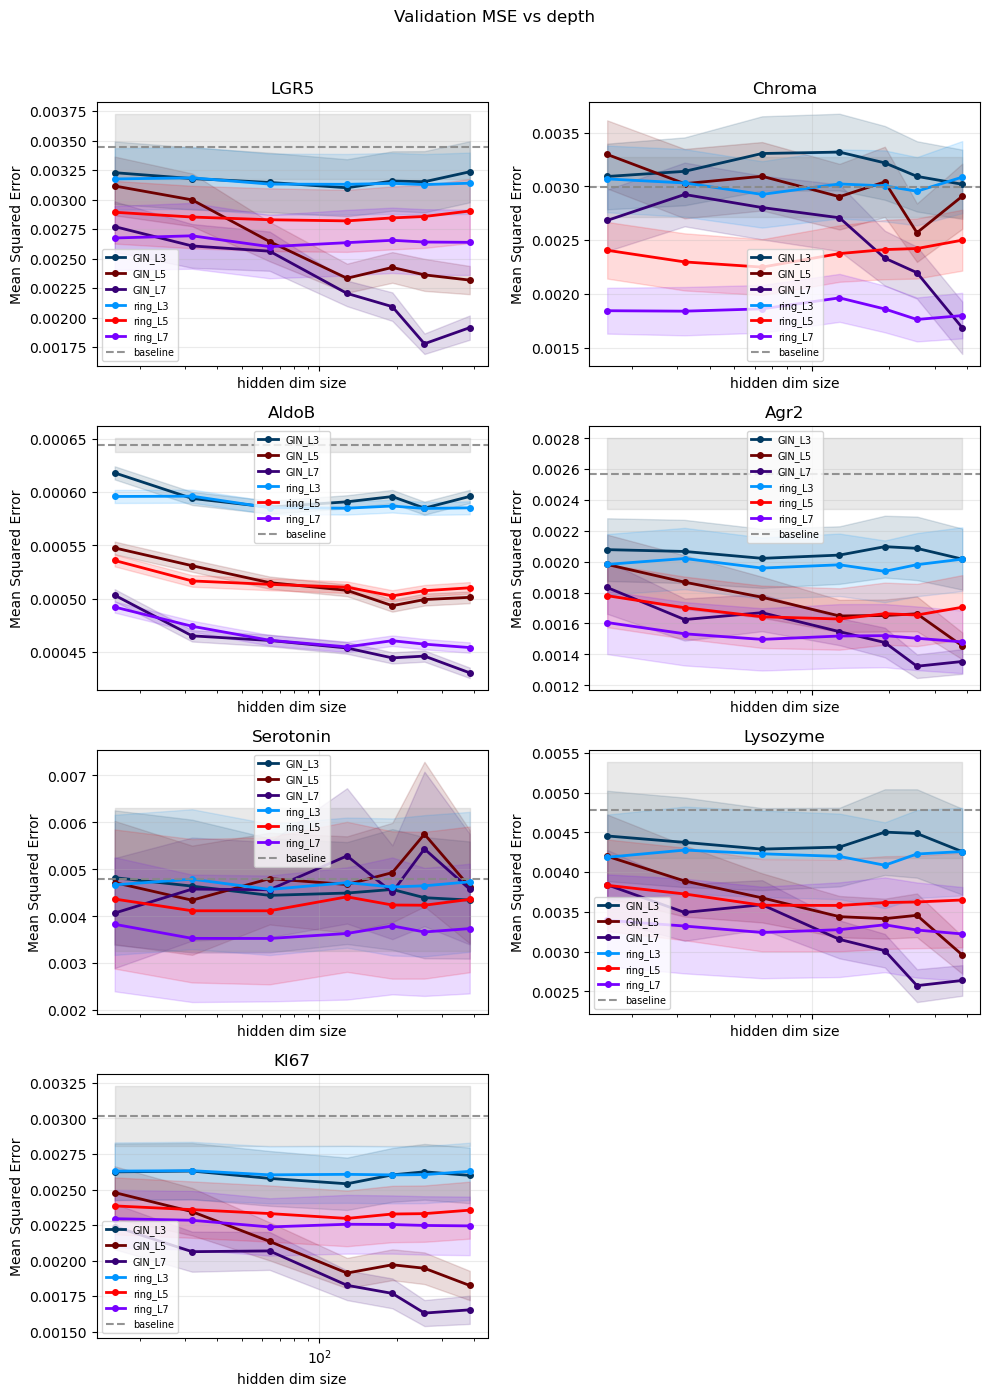

In [12]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN_L3": "#003961",
    "GIN_L5": "#6e0000",
    "GIN_L7": "#370075",
    "ring_L3": "#0095ff",
    "ring_L5": "#ff0000",
    "ring_L7": "#7700ff",
}


family_order = [
    "GIN_L3",
    "GIN_L5",
    "GIN_L7",
    "ring_L3",
    "ring_L5",
    "ring_L7",
]


fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)

# modify afterwards
for ax in axes:
    ax.set_xticks(hidden_dims)
    ax.set_xticklabels([f"{v}" for v in hidden_dims])
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

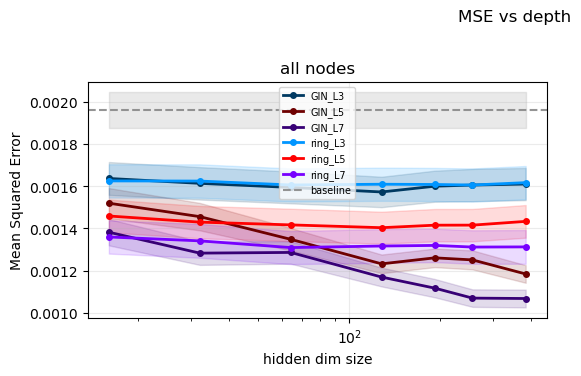

In [13]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

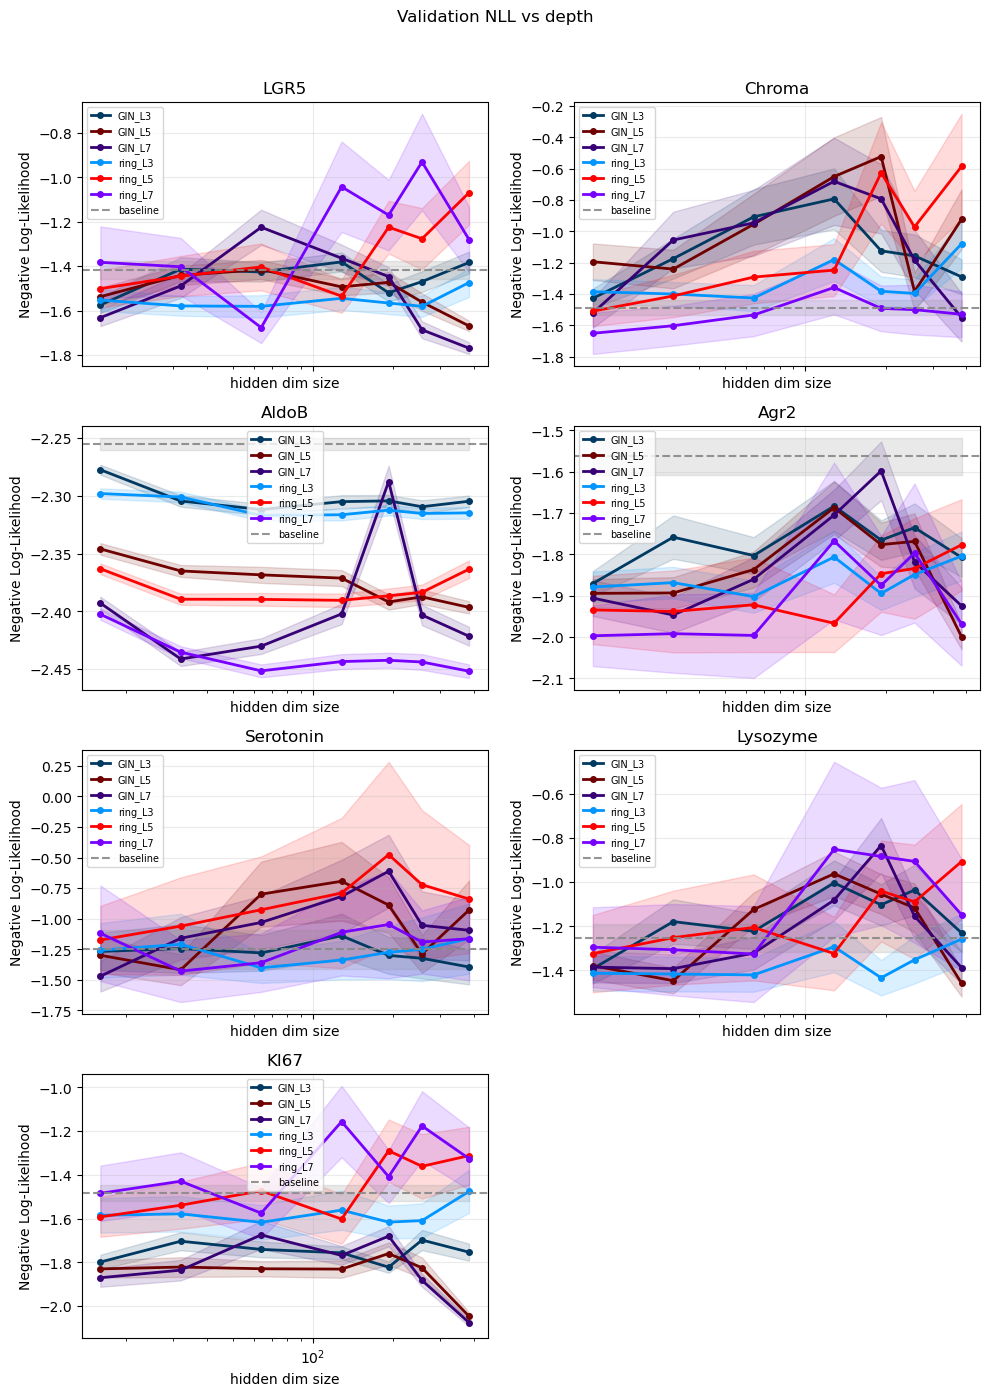

In [14]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

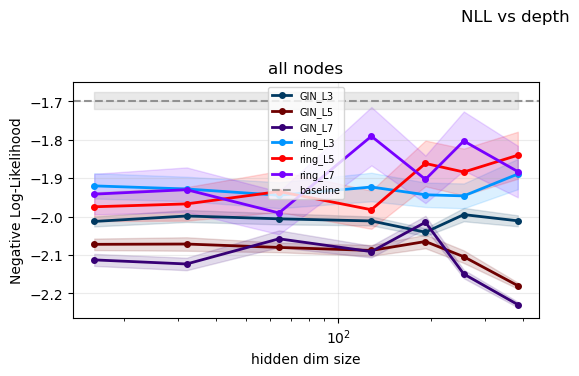

In [15]:
fig, axes = plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

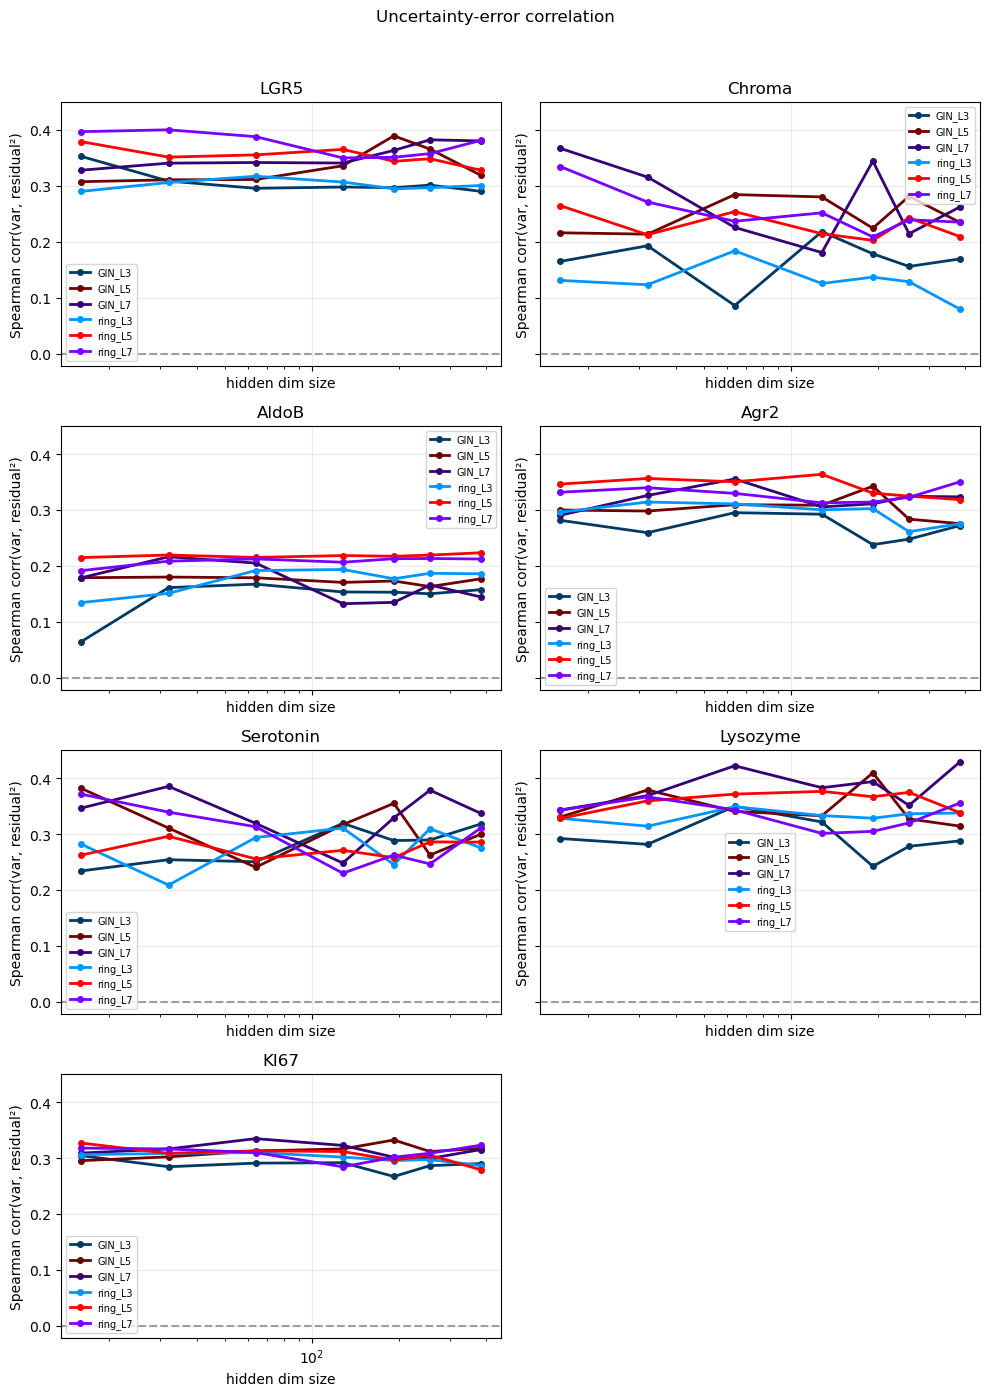

In [16]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=hidden_dims,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

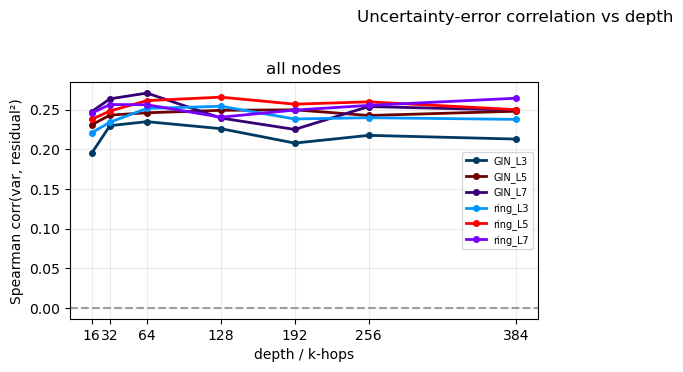

In [17]:
plot_all_aggregates_metric_vs_depth(
    eval_results,
    hidden_dims,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
# modify afterwards
for ax in axes:
    ax.set_xlabel("hidden dim size")
    ax.set_xscale("log") 

plt.show()

In [18]:
import json
import pickle
from pathlib import Path
from datetime import datetime


def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved joint experiment → {save_dir}")

In [20]:
joint_config = {
    "experiment_group": "compare_models",

    "model_families": list(trained_models.keys()),
    "depths": num_layers_list,

    "hidden_dims": hidden_dims,
    "dropout": 0.1,
    "norm": "batch",

    "train_config": {
        "loss_name": cfg.loss_name,
        "lr": cfg.lr,
        "batch_size": cfg.batch_size,
        "max_epochs": cfg.max_epochs,
        "patience": cfg.patience,
        "num_workers": cfg.num_workers,
    },

    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),

    "marker_names": list(marker_names),
}

In [21]:
results_by_experiment = {
    "eval_results": eval_results,
}

save_dir = PROJECT_ROOT / "results_experiments" / "model_size_scan" / "run_001"

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes="Compare performance as function of model size for different depths",
)

Saved joint experiment → /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/model_size_scan/run_001
